# Day 38 - Customer Retention and Lifetime Value

## Step 1 - Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os
import warnings
warnings.filterwarnings('ignore')

# Set professional plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 10

print("Required libraries imported successfully.")


Required libraries imported successfully.


## Step 2 - Simulate Customer Transactions

In [2]:
np.random.seed(42)
n_customers = 1500
customer_ids = [f"CUST_{i:04d}" for i in range(1, n_customers + 1)]

# Signup dates distributed across 2024
start_date = pd.to_datetime("2024-01-01")
end_date = pd.to_datetime("2024-12-31")
days_range = (end_date - start_date).days
signup_offsets = np.random.randint(0, days_range + 1, size=n_customers)
signup_dates = start_date + pd.to_timedelta(signup_offsets, unit="D")

# Persona distribution
personas = np.random.choice(
    ["High-Value", "Standard", "Low-Value", "One-Time"],
    size=n_customers,
    p=[0.15, 0.50, 0.25, 0.10]
)

customer_df = pd.DataFrame({
    "CustomerID": customer_ids,
    "SignupDate": signup_dates,
    "Persona": personas
})

# Generate transaction logs through December 2025
transactions = []

for idx, row in customer_df.iterrows():
    cid = row["CustomerID"]
    signup = row["SignupDate"]
    persona = row["Persona"]
    
    # First purchase occurs on signup date
    first_amount = round(np.random.normal(
        150 if persona == "High-Value" else (60 if persona == "Standard" else (25 if persona == "Low-Value" else 40)),
        25 if persona == "High-Value" else (12 if persona == "Standard" else (5 if persona == "Low-Value" else 10))
    ), 2)
    transactions.append({
        "CustomerID": cid,
        "TransactionDate": signup,
        "TransactionAmount": max(5.0, first_amount)
    })
    
    if persona == "One-Time":
        continue
        
    signup_month = signup.to_period("M")
    obs_months = pd.period_range(start=signup_month + 1, end="2025-12", freq="M")
    
    # Set monthly churn probability
    churn_prob = 0.03 if persona == "High-Value" else (0.08 if persona == "Standard" else 0.22)
    
    has_churned = False
    for m in obs_months:
        if has_churned:
            break
        # Check if customer churns this month
        if np.random.rand() < churn_prob:
            has_churned = True
            break
            
        # Determine number of purchases
        if persona == "High-Value":
            n_purchases = np.random.randint(1, 4)
        elif persona == "Standard":
            n_purchases = np.random.choice([0, 1, 2], p=[0.3, 0.5, 0.2])
        else:
            n_purchases = np.random.choice([0, 1], p=[0.7, 0.3])
            
        for _ in range(n_purchases):
            m_start = m.to_timestamp()
            days_in_month = m.day
            day_offset = np.random.randint(0, days_in_month)
            tx_date = m_start + pd.to_timedelta(day_offset, unit="D")
            
            tx_amount = np.random.normal(
                140 if persona == "High-Value" else (55 if persona == "Standard" else 22),
                20 if persona == "High-Value" else (10 if persona == "Standard" else 4)
            )
            transactions.append({
                "CustomerID": cid,
                "TransactionDate": tx_date,
                "TransactionAmount": round(max(5.0, tx_amount), 2)
            })

tx_df = pd.DataFrame(transactions)
tx_df.sort_values(by="TransactionDate", inplace=True)
tx_df.reset_index(drop=True, inplace=True)

print(f"Dataset generated. Shape: {tx_df.shape}")
print(f"Date range: {tx_df['TransactionDate'].min().date()} to {tx_df['TransactionDate'].max().date()}")
print(tx_df.head())


Dataset generated. Shape: (14138, 3)
Date range: 2024-01-01 to 2025-12-31
  CustomerID TransactionDate  TransactionAmount
0  CUST_0758      2024-01-01              49.71
1  CUST_0448      2024-01-01              82.99
2  CUST_1167      2024-01-01              23.26
3  CUST_0851      2024-01-01              86.51
4  CUST_1031      2024-01-01             144.44


## Step 3 - Calculate Customer Retention Metrics

In [3]:
tx_df["TransactionMonth"] = tx_df["TransactionDate"].dt.to_period("M")
tx_df["CohortMonth"] = tx_df.groupby("CustomerID")["TransactionDate"].transform("min").dt.to_period("M")

# Calculate monthly distance
tx_df["CohortIndex"] = (tx_df["TransactionMonth"].dt.year - tx_df["CohortMonth"].dt.year) * 12 + (tx_df["TransactionMonth"].dt.month - tx_df["CohortMonth"].dt.month)

# Calculate active customer counts per cohort and index
cohort_counts = tx_df.groupby(["CohortMonth", "CohortIndex"])["CustomerID"].nunique().reset_index()
cohort_pivot = cohort_counts.pivot(index="CohortMonth", columns="CohortIndex", values="CustomerID")

# Calculate retention rate percentages
cohort_sizes = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0)

print("Cohort Sizes (Number of Customers):")
print(cohort_sizes)
print("\nRetention Matrix (First 5 Months):")
print(retention_matrix.iloc[:, :5].round(3))


Cohort Sizes (Number of Customers):
CohortMonth
2024-01    123.0
2024-02    128.0
2024-03     96.0
2024-04    138.0
2024-05    144.0
2024-06    127.0
2024-07    106.0
2024-08    142.0
2024-09    118.0
2024-10    134.0
2024-11    120.0
2024-12    124.0
Freq: M, Name: 0, dtype: float64

Retention Matrix (First 5 Months):
CohortIndex    0      1      2      3      4
CohortMonth                                 
2024-01      1.0  0.553  0.528  0.463  0.447
2024-02      1.0  0.562  0.453  0.484  0.461
2024-03      1.0  0.562  0.500  0.479  0.448
2024-04      1.0  0.536  0.413  0.420  0.428
2024-05      1.0  0.569  0.486  0.424  0.403
2024-06      1.0  0.433  0.433  0.402  0.378
2024-07      1.0  0.557  0.500  0.462  0.368
2024-08      1.0  0.556  0.458  0.437  0.408
2024-09      1.0  0.500  0.449  0.415  0.432
2024-10      1.0  0.530  0.478  0.470  0.425
2024-11      1.0  0.550  0.533  0.483  0.392
2024-12      1.0  0.395  0.444  0.403  0.395


## Step 4 - RFM Customer Segmentation

In [4]:
# Reference date is one day after the last transaction
analysis_date = tx_df["TransactionDate"].max() + pd.to_timedelta(1, unit="D")

rfm = tx_df.groupby("CustomerID").agg({
    "TransactionDate": lambda x: (analysis_date - x.max()).days,
    "CustomerID": "count",
    "TransactionAmount": "sum"
}).rename(columns={
    "TransactionDate": "Recency",
    "CustomerID": "Frequency",
    "TransactionAmount": "Monetary"
})

# Quantile scoring (1-4)
rfm["R_Score"] = pd.qcut(rfm["Recency"], q=4, labels=[4, 3, 2, 1])  # Recent purchase gets score 4
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), q=4, labels=[1, 2, 3, 4])
rfm["M_Score"] = pd.qcut(rfm["Monetary"], q=4, labels=[1, 2, 3, 4])

def assign_segment(row):
    r, f, m = int(row["R_Score"]), int(row["F_Score"]), int(row["M_Score"])
    if r >= 3 and f >= 3 and m >= 3:
        return "Champions"
    elif r >= 2 and f >= 2 and m >= 3:
        return "Loyal Customers"
    elif r >= 3 and f <= 2:
        return "New Customers"
    elif r <= 2 and f >= 2:
        return "At Risk"
    else:
        return "Lost"

rfm["Segment"] = rfm.apply(assign_segment, axis=1)

print("Customer Counts by Segment:")
print(rfm["Segment"].value_counts())


Customer Counts by Segment:


Segment
Champions          615
Lost               383
At Risk            302
New Customers      104
Loyal Customers     96
Name: count, dtype: int64


## Step 5 - Estimate Customer Lifetime Value

In [5]:
margin = 0.80

# Calculate AOV and Monthly Purchase Frequency
first_tx = tx_df.groupby("CustomerID")["TransactionDate"].min()
last_tx = tx_df.groupby("CustomerID")["TransactionDate"].max()

rfm = rfm.join(first_tx.rename("FirstTx"))
rfm = rfm.join(last_tx.rename("LastTx"))

# Observation period in months
rfm["ObsPeriodMonths"] = ((analysis_date - rfm["FirstTx"]).dt.days / 30.0).apply(np.ceil).clip(lower=1)
rfm["AOV"] = rfm["Monetary"] / rfm["Frequency"]
rfm["MonthlyFreq"] = rfm["Frequency"] / rfm["ObsPeriodMonths"]

# Define churn rates per segment based on empirical persona properties
segment_churn_rates = {
    "Champions": 0.02,        # Low churn
    "Loyal Customers": 0.05,  # Moderate-low churn
    "New Customers": 0.15,    # High churn (untested loyalty)
    "At Risk": 0.25,          # Very high churn risk
    "Lost": 1.00              # Already churned
}

rfm["SegmentChurnRate"] = rfm["Segment"].map(segment_churn_rates)

# Historical CLV (margin adjusted)
rfm["Historical_CLV"] = (rfm["Monetary"] * margin).round(2)

# Predictive CLV = Historical + Expected Future Value
future_val = (rfm["AOV"] * rfm["MonthlyFreq"] * margin) / rfm["SegmentChurnRate"]
rfm["Predictive_CLV"] = (rfm["Historical_CLV"] + future_val).round(2)

print("CLV Summary statistics:")
print(rfm[["Historical_CLV", "Predictive_CLV"]].describe().round(2))


CLV Summary statistics:
       Historical_CLV  Predictive_CLV
count         1500.00         1500.00
mean           710.58         2451.87
std           1280.75         4552.30
min              9.23            9.63
25%             38.13           44.41
50%            182.71          236.27
75%            621.52         2272.77
max           6139.92        18530.93


## Step 6 - Visualize Retention and CLV Trends

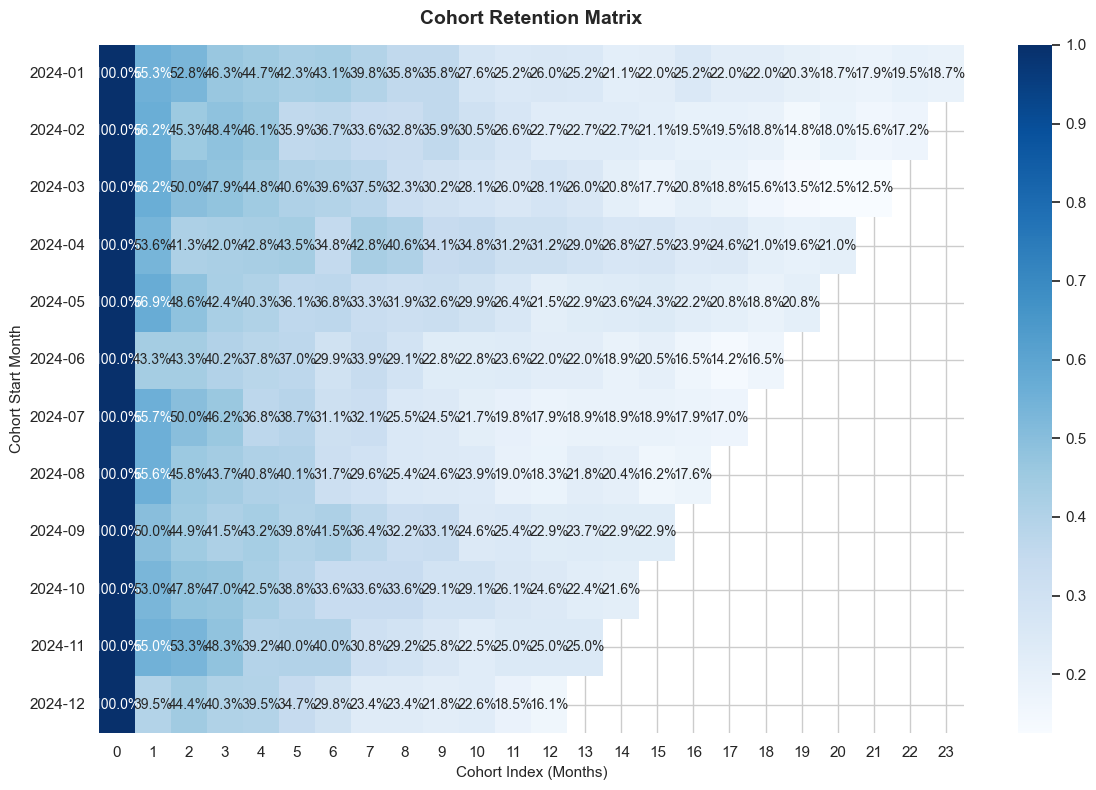

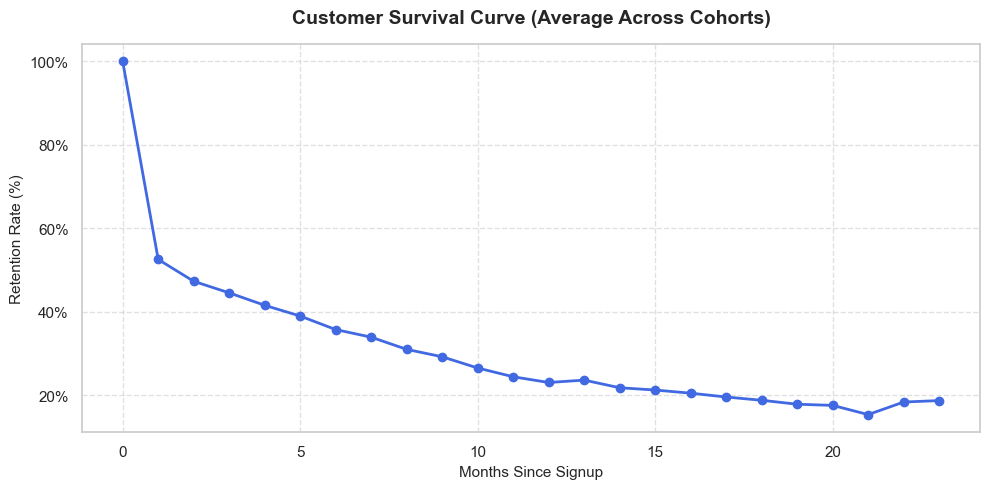

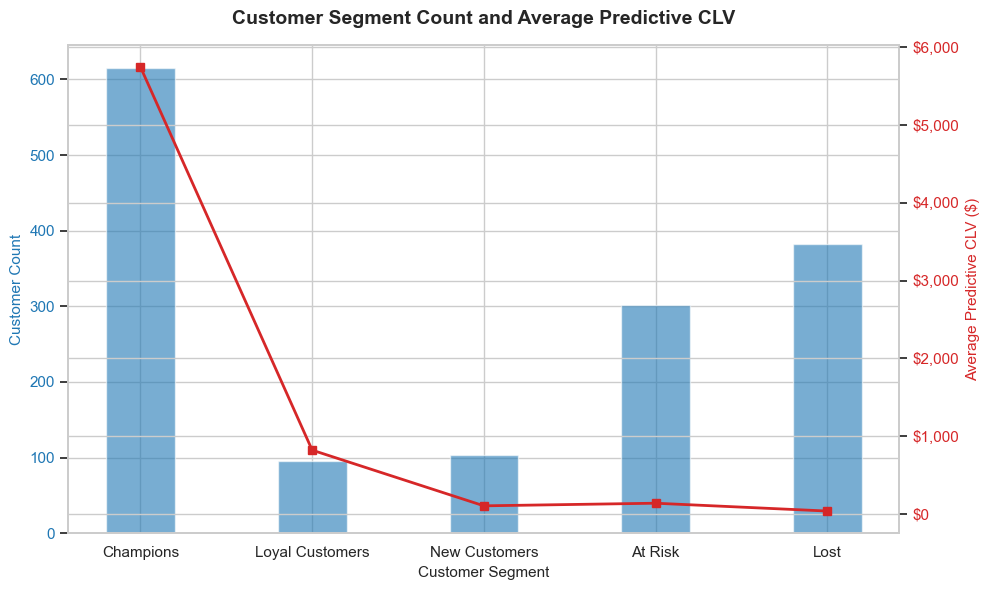

Plots successfully saved as PNG files in the 'day38' directory.


In [6]:
# 1. Cohort Retention Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    retention_matrix, 
    annot=True, 
    fmt=".1%", 
    cmap="Blues", 
    cbar=True, 
    yticklabels=retention_matrix.index.strftime('%Y-%m')
)
plt.title("Cohort Retention Matrix", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Cohort Index (Months)", fontsize=11)
plt.ylabel("Cohort Start Month", fontsize=11)
plt.tight_layout()
plt.savefig("cohort_retention_heatmap.png", dpi=150)
plt.show()
plt.close()

# 2. Customer Survival Curve
plt.figure(figsize=(10, 5))
avg_retention = retention_matrix.mean(axis=0)
plt.plot(avg_retention.index, avg_retention.values, marker='o', linewidth=2, color='royalblue')
plt.title("Customer Survival Curve (Average Across Cohorts)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Months Since Signup", fontsize=11)
plt.ylabel("Retention Rate (%)", fontsize=11)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("customer_survival_curve.png", dpi=150)
plt.show()
plt.close()

# 3. RFM Segment Count and Average CLV
segment_stats = rfm.groupby('Segment').agg({
    'Monetary': 'count',
    'Predictive_CLV': 'mean'
}).rename(columns={'Monetary': 'CustomerCount'}).reindex(['Champions', 'Loyal Customers', 'New Customers', 'At Risk', 'Lost'])

fig, ax1 = plt.subplots(figsize=(10, 6))

color = '#1f77b4'
ax1.set_xlabel('Customer Segment', fontsize=11)
ax1.set_ylabel('Customer Count', color=color, fontsize=11)
bars = ax1.bar(segment_stats.index, segment_stats['CustomerCount'], color=color, alpha=0.6, width=0.4, label='Customer Count')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = '#d62728'
ax2.set_ylabel('Average Predictive CLV ($)', color=color, fontsize=11)
line = ax2.plot(segment_stats.index, segment_stats['Predictive_CLV'], color=color, marker='s', linewidth=2, label='Avg Predictive CLV')
ax2.tick_params(axis='y', labelcolor=color)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.title("Customer Segment Count and Average Predictive CLV", fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.savefig("customer_segments_clv.png", dpi=150)
plt.show()
plt.close()

print("Plots successfully saved as PNG files in the 'day38' directory.")


## Step 7 - Export Results

In [7]:
# Calculate segment aggregates
segment_summary = rfm.groupby("Segment").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean",
    "Historical_CLV": "mean",
    "Predictive_CLV": "mean"
}).round(2).reindex(['Champions', 'Loyal Customers', 'New Customers', 'At Risk', 'Lost'])

segment_summary.to_csv("customer_segment_summary.csv")
print("Aggregated segment statistics:")
print(segment_summary)


Aggregated segment statistics:
                 Recency  Frequency  Monetary  Historical_CLV  Predictive_CLV
Segment                                                                      
Champions         117.37      19.27   1971.35         1577.08         5743.71
Loyal Customers   427.29       7.34    521.60          417.28          819.91
New Customers     305.21       2.64     89.36           71.49          104.25
At Risk           533.57       2.70    144.81          115.85          137.88
Lost              528.25       1.29     44.00           35.20           37.18
